# Quick Example: NUTS over effectful models

This notebook walks through three short demos that show what `effectful_mcmc` looks like in practice. We start with a basic Bayesian linear regression, then move to a small hierarchical model (the classic eight schools), and finish with a counterfactual analysis that exercises what the bridge is actually *for* — composing handlers with MCMC.

Distributions come from `effectful.handlers.numpyro` (term-aware constructors that accept both eager arrays and free-variable terms). The primitives `sample`, `factor`, `param`, `deterministic` are `@defop`s, so any effectful handler can intercept them.

To run this locally:

```bash
pip install -e .
jupyter notebook docs/quickstart.ipynb
```

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr

import matplotlib.pyplot as plt
import numpy as np

from effectful.handlers.numpyro import Normal, HalfNormal
from effectful.ops.semantics import handler

from effectful_mcmc import sample, MCMC, NUTS, Intervene

jax.config.update("jax_platform_name", "cpu")  # demo is small enough that CPU is fastest

/Users/datnguyen/HMC_NUTS_Effectful/effectful_mcmc/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Linear regression

A small synthetic dataset: $N = 50$ points drawn from $y = \alpha + \beta\, x + \varepsilon$ with $\alpha = 2.0$, $\beta = -1.5$, and $\varepsilon \sim \mathcal{N}(0, 0.5)$. We then infer the posterior over $\alpha, \beta, \sigma$ using

$$
\alpha \sim \mathcal{N}(0, 10), \quad
\beta \sim \mathcal{N}(0, 10), \quad
\sigma \sim \mathrm{HalfNormal}(2).
$$

The model just calls `sample(...)` once per parameter and once for the likelihood. Returning the per-site terms lets us index `mcmc.get_samples()` by `term.op` directly — no string names to keep in sync. (Pass `name=` to `sample(...)` if you also want string-keyed access, e.g. for ArviZ or for `Intervene`; we do this in section 3.)

In [2]:
# Synthetic regression dataset
true_alpha, true_beta, true_sigma = 2.0, -1.5, 0.5
N = 50

key_data = jr.PRNGKey(0)
k_x, k_noise = jr.split(key_data)
x_data = jr.uniform(k_x, (N,), minval=-2.0, maxval=2.0)
y_data = true_alpha + true_beta * x_data + true_sigma * jr.normal(k_noise, (N,))

print(f"Generated {N} points with alpha={true_alpha}, beta={true_beta}, sigma={true_sigma}")

Generated 50 points with alpha=2.0, beta=-1.5, sigma=0.5


In [3]:
def linear_regression(x, y):
    alpha = sample(Normal(0.0, 10.0))
    beta  = sample(Normal(0.0, 10.0))
    sigma = sample(HalfNormal(2.0))
    sample(Normal(alpha + beta * x, sigma), obs=y)
    return alpha, beta, sigma                          # return per-site handles

mcmc = MCMC(NUTS(linear_regression), num_warmup=500, num_samples=1000, progress_bar=False)
mcmc.run(jr.PRNGKey(1), x_data, y_data)

# Posteriors keyed by the underlying Operation — `term.op` recovers it.
alpha_t, beta_t, sigma_t = mcmc.model_return_value
samples = mcmc.get_samples()

for term, label, true in [(alpha_t, "alpha", true_alpha),
                          (beta_t,  "beta",  true_beta),
                          (sigma_t, "sigma", true_sigma)]:
    post = samples[term.op]
    print(f"{label}: posterior mean = {float(post.mean()):+.3f}  "
          f"std = {float(post.std()):.3f}  (truth = {true:+.2f})")

alpha: posterior mean = +1.771  std = 0.083  (truth = +2.00)
beta: posterior mean = -1.481  std = 0.065  (truth = -1.50)
sigma: posterior mean = +0.570  std = 0.059  (truth = +0.50)


The chain recovers each parameter close to its true value — the posterior means are within roughly a couple of posterior std, which is the kind of finite-sample sampling noise you expect from $N = 50$ noisy observations rather than anything to investigate.

`mcmc.print_summary()` reuses NumPyro's own diagnostic table, since the bridge forwards post-run attribute access to `numpyro.infer.MCMC` via `__getattr__`. The site labels look like `_site_<hex>` because we didn't pass `name=` to the `sample(...)` calls; for ArviZ-style string keys, add `name="alpha"` etc.

In [4]:
mcmc.print_summary()


                       mean       std    median      5.0%     95.0%     n_eff     r_hat
  _site_115ba8f20      1.77      0.08      1.77      1.64      1.91   1080.79      1.00
  _site_115becf80     -1.48      0.06     -1.48     -1.59     -1.38    841.94      1.00
  _site_115c0d0d0      0.57      0.06      0.56      0.48      0.67    862.90      1.00

Number of divergences: 0


### Posterior diagnostics

The standard NUTS-paper-style diagnostics (Hoffman & Gelman, 2014 — Figs. 7–8): a **trace plot** per parameter to check the chain mixed and didn't stick, plus the **marginal posterior density** with the data-generating truth overlaid as a vertical line. Healthy chains look like white noise around a flat mean; the marginals should put non-trivial mass near the truth.

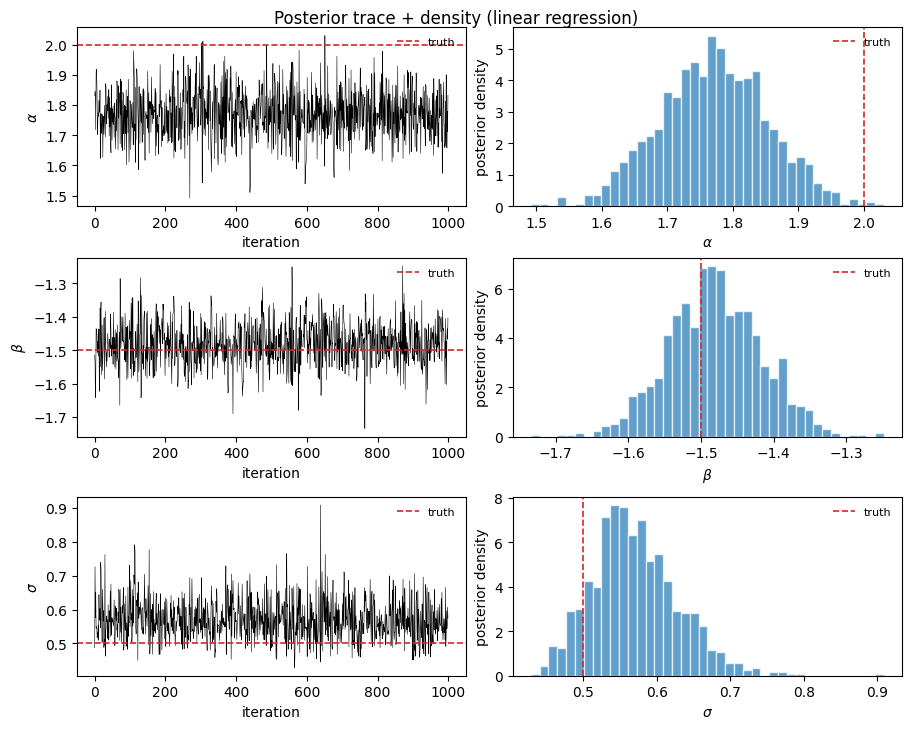

In [5]:
def trace_and_density(axes_row, draws, label, truth):
    ax_trace, ax_density = axes_row
    draws = np.asarray(draws)
    ax_trace.plot(draws, lw=0.4, color="black")
    ax_trace.axhline(truth, color="C3", lw=1.2, ls="--", label="truth")
    ax_trace.set_xlabel("iteration")
    ax_trace.set_ylabel(label)
    ax_trace.legend(loc="upper right", frameon=False, fontsize=8)

    ax_density.hist(draws, bins=40, density=True, color="C0", alpha=0.7, edgecolor="white")
    ax_density.axvline(truth, color="C3", lw=1.2, ls="--", label="truth")
    ax_density.set_xlabel(label)
    ax_density.set_ylabel("posterior density")
    ax_density.legend(loc="upper right", frameon=False, fontsize=8)

fig, axes = plt.subplots(3, 2, figsize=(9, 7), constrained_layout=True)
for row, (term, label, truth) in enumerate([
    (alpha_t, r"$\alpha$", true_alpha),
    (beta_t,  r"$\beta$",  true_beta),
    (sigma_t, r"$\sigma$", true_sigma),
]):
    trace_and_density(axes[row], samples[term.op], label, truth)
fig.suptitle("Posterior trace + density (linear regression)", y=1.02)
plt.show()

## 2. Eight schools

Eight schools each ran a coaching program and reported an estimated treatment effect $y_j$ together with an observational standard error $\sigma_j$. The hierarchical model partially pools the school-level effects $\theta_j$ toward a shared population mean $\mu$ with a shared spread $\tau$:

$$
\mu \sim \mathcal{N}(0, 10), \quad
\tau \sim \mathrm{HalfNormal}(10), \quad
\theta_j \sim \mathcal{N}(\mu, \tau), \quad
y_j \sim \mathcal{N}(\theta_j, \sigma_j).
$$

Written in the per-element idiom — one explicit `sample` per school — which the bridge supports today without needing any `plate` machinery. Sites are named here so we can address each $\theta_j$ and $y_j$ by `f"theta_{j}"` / `f"y_{j}"` from the surrounding Python loop.

In [6]:
# Rubin (1981) data
y_obs    = jnp.array([28.0,  8.0, -3.0,  7.0, -1.0,  1.0, 18.0, 12.0])
sigma_obs = jnp.array([15.0, 10.0, 16.0, 11.0,  9.0, 11.0, 10.0, 18.0])
J = len(y_obs)

def eight_schools(y, sigma):
    mu  = sample(Normal(0.0, 10.0), name="mu")
    tau = sample(HalfNormal(10.0),   name="tau")
    for j in range(J):
        theta_j = sample(Normal(mu, tau), name=f"theta_{j}")
        sample(Normal(theta_j, sigma[j]), obs=y[j], name=f"y_{j}")

mcmc8 = MCMC(NUTS(eight_schools), num_warmup=1000, num_samples=2000, progress_bar=False)
mcmc8.run(jr.PRNGKey(2), y_obs, sigma_obs)
samples8 = mcmc8.get_samples_by_name()

print(f"mu   posterior: mean = {float(samples8['mu'].mean()):+.2f}  std = {float(samples8['mu'].std()):.2f}")
print(f"tau  posterior: mean = {float(samples8['tau'].mean()):+.2f}  std = {float(samples8['tau'].std()):.2f}")
print("per-school theta posteriors:")
for j in range(J):
    th = samples8[f"theta_{j}"]
    print(f"  school {j}: mean = {float(th.mean()):+6.2f}  std = {float(th.std()):.2f}  (raw y_{j} = {float(y_obs[j]):+.1f})")

mu   posterior: mean = +5.92  std = 3.03
tau  posterior: mean = +2.33  std = 3.15
per-school theta posteriors:
  school 0: mean =  +6.99  std = 4.66  (raw y_0 = +28.0)
  school 1: mean =  +6.09  std = 3.97  (raw y_1 = +8.0)
  school 2: mean =  +5.57  std = 4.41  (raw y_2 = -3.0)
  school 3: mean =  +6.01  std = 4.03  (raw y_3 = +7.0)
  school 4: mean =  +5.28  std = 4.03  (raw y_4 = -1.0)
  school 5: mean =  +5.45  std = 4.04  (raw y_5 = +1.0)
  school 6: mean =  +6.89  std = 4.11  (raw y_6 = +18.0)
  school 7: mean =  +6.09  std = 4.57  (raw y_7 = +12.0)


The headline effect is **shrinkage**. Raw observations span $-3$ to $+28$, but every $\theta_j$ posterior mean lives within roughly $\pm 2$ of $\mu \approx 5.9$ — the hierarchical prior absorbs the school-level noise by pulling each effect toward the population mean. School $0$ ($y_0 = +28$) is the most dramatic example: its posterior mean is only $+7.0$ because the population scale $\tau \approx 2.3$ makes $28$ look like a large noise excursion rather than a real signal.

### Forest plot

The textbook hierarchical-Bayes visualization: each school's posterior $\theta_j$ as a credible interval (squares), with the raw $y_j \pm \sigma_j$ alongside (circles) for contrast. The gap between each raw observation and its posterior interval is exactly the shrinkage the hierarchical prior is producing.

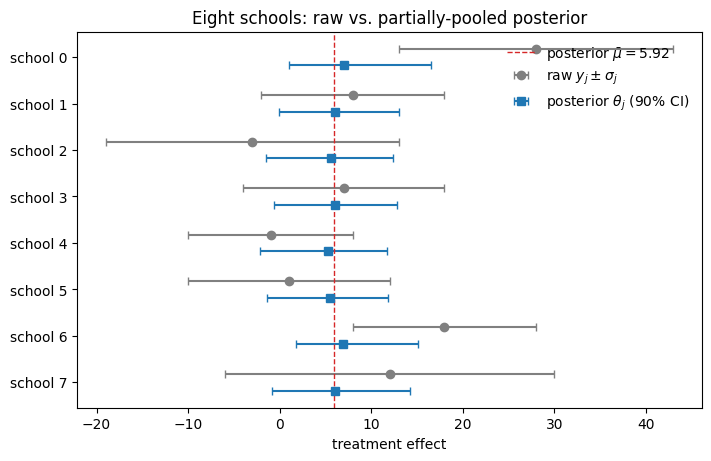

In [7]:
theta_means = np.array([float(samples8[f"theta_{j}"].mean())            for j in range(J)])
theta_lo    = np.array([float(np.quantile(samples8[f"theta_{j}"], 0.05)) for j in range(J)])
theta_hi    = np.array([float(np.quantile(samples8[f"theta_{j}"], 0.95)) for j in range(J)])
mu_mean     = float(samples8["mu"].mean())

y_arr = np.asarray(y_obs)
s_arr = np.asarray(sigma_obs)
yloc  = np.arange(J)

fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
# raw observations with reported standard errors
ax.errorbar(y_arr, yloc - 0.18, xerr=s_arr, fmt="o", color="gray", capsize=3,
            label=r"raw $y_j \pm \sigma_j$")
# posterior 90% credible intervals for each theta_j
ax.errorbar(theta_means, yloc + 0.18,
            xerr=[theta_means - theta_lo, theta_hi - theta_means],
            fmt="s", color="C0", capsize=3, label=r"posterior $\theta_j$ (90% CI)")
ax.axvline(mu_mean, color="C3", ls="--", lw=1, label=fr"posterior $\bar{{\mu}} = {mu_mean:.2f}$")
ax.set_yticks(yloc)
ax.set_yticklabels([f"school {j}" for j in range(J)])
ax.invert_yaxis()
ax.set_xlabel("treatment effect")
ax.set_title("Eight schools: raw vs. partially-pooled posterior")
ax.legend(loc="upper right", frameon=False)
plt.show()

## 3. Counterfactual via `Intervene`

The eight-schools model from section 2 has a single knob, the population scale $\tau$, that controls how aggressively the school-level effects are pooled toward $\mu$. Small $\tau$ means strong pooling (every $\theta_j$ ends up near $\mu$); large $\tau$ means weak or no pooling (each $\theta_j$ tracks its own $y_j$). The data picked out $\tau \approx 2.3$ on its own, giving moderate shrinkage.

The natural epistemic question is: *what would the per-school posteriors look like if we held $\tau$ fixed at much smaller or much larger values?* That's a counterfactual — we want to "intervene" on $\tau$, break its dependence on the data, and re-run inference under the intervention.

`Intervene(name, value)` is the handler that does this. It's a ~10-line subclass of `ObjectInterpretation` (in `effectful_mcmc/__init__.py`) that intercepts the `sample` defop and overrides the named site. Wrapping the section-2 model in `with handler(Intervene("tau", value))` and passing it back through `MCMC(NUTS(...))` is the entire bridging code — the intervention survives the compile-time trace and per-step potential evaluation untouched.

The intervened site is **removed** from the posterior (the user already passed the value in), and every remaining site conditions on the intervention as if $\tau$ had been observed.

In [8]:
# Two counterfactual scenarios layered on top of section 2's `eight_schools`
# model with NO change to it. `Intervene` is the only new code we write.
def eight_schools_strong_pooling(y, sigma):
    with handler(Intervene("tau", jnp.array(0.5))):
        eight_schools(y, sigma)

def eight_schools_no_pooling(y, sigma):
    with handler(Intervene("tau", jnp.array(20.0))):
        eight_schools(y, sigma)

mcmc_strong = MCMC(NUTS(eight_schools_strong_pooling),
                   num_warmup=1000, num_samples=2000, progress_bar=False)
mcmc_strong.run(jr.PRNGKey(4), y_obs, sigma_obs)
samples_strong = mcmc_strong.get_samples_by_name()

mcmc_none = MCMC(NUTS(eight_schools_no_pooling),
                 num_warmup=1000, num_samples=2000, progress_bar=False)
mcmc_none.run(jr.PRNGKey(5), y_obs, sigma_obs)
samples_none = mcmc_none.get_samples_by_name()

def summarize(samples_dict, label):
    theta_means = [float(samples_dict[f"theta_{j}"].mean()) for j in range(J)]
    spread = max(theta_means) - min(theta_means)
    formatted = "  ".join(f"{m:+5.1f}" for m in theta_means)
    print(f"  {label}")
    print(f"    per-school theta means:  {formatted}")
    print(f"    spread (max - min) = {spread:.2f}")

print("Per-school posteriors under three regimes for tau:")
summarize(samples8,       "baseline (tau inferred, posterior mean ~ 2.3)")
summarize(samples_strong, "intervened: tau = 0.5  (strong pooling)")
summarize(samples_none,   "intervened: tau = 20   (no pooling)")

print("\n'tau' present in each get_samples_by_name():")
print(f"  baseline:        {'tau' in samples8}")
print(f"  strong pooling:  {'tau' in samples_strong}")
print(f"  no pooling:      {'tau' in samples_none}")
print("(intervened tau is absent -- the user already supplied the value)")

Per-school posteriors under three regimes for tau:
  baseline (tau inferred, posterior mean ~ 2.3)
    per-school theta means:   +7.0   +6.1   +5.6   +6.0   +5.3   +5.5   +6.9   +6.1
    spread (max - min) = 1.72
  intervened: tau = 0.5  (strong pooling)
    per-school theta means:   +6.6   +6.6   +6.6   +6.6   +6.6   +6.6   +6.6   +6.6
    spread (max - min) = 0.08
  intervened: tau = 20   (no pooling)
    per-school theta means:  +19.5   +7.5   +0.3   +6.7   -0.4   +2.1  +15.4   +8.6
    spread (max - min) = 19.95

'tau' present in each get_samples_by_name():
  baseline:        True
  strong pooling:  False
  no pooling:      False
(intervened tau is absent -- the user already supplied the value)


The three regimes pull dramatically different shapes from the same data:

- **Baseline** ($\tau \approx 2.3$, inferred): moderate shrinkage. School 0's posterior mean drops from $y_0 = +28$ to about $+7$; the per-school spread is roughly $1.7$.
- **Strong pooling** ($\tau = 0.5$, intervened): every school's posterior mean collapses to within a fraction of a unit of $\mu \approx 6.6$ — the data can hardly move any individual $\theta_j$ away from the population mean. The per-school spread shrinks to about $0.08$, more than $20\times$ tighter than the baseline.
- **No pooling** ($\tau = 20$, intervened): each $\theta_j$ tracks its own $y_j$ much more closely; school 0 climbs from $+7$ (baseline) up to $+19.5$ — most of the way to $y_0 = +28$, the rest absorbed into the school's own observation noise $\sigma_0 = 15$. School 2 falls back to $+0.3$, close to its raw $y_2 = -3$. The per-school spread balloons to nearly $20$, an order of magnitude larger than the baseline.

The point isn't that any of these is "the right answer" — the baseline is. The point is that **the same `Intervene` handler turned a single-paragraph model into three distinct epistemic experiments**, with no MCMC-specific intervention API to learn. The same handler works under prior simulation, SVI, or any custom inference scheme that routes through `sample`. Custom handlers (conditioning, masking, ablation, ...) follow the same pattern: subclass `ObjectInterpretation`, decorate with `@implements(sample)` / `@implements(factor)` / etc., and stack with `with handler(MyHandler())`.

### Forest plot per pooling regime

Three forest plots side-by-side make the shrinkage spectrum visible at a glance. Under strong pooling every $\theta_j$ collapses toward $\mu$ (the credible intervals overlap heavily); under no pooling each school recovers its raw $y_j \pm \sigma_j$ (back to the unpooled estimate); the inferred baseline lands in between, which is exactly what hierarchical Bayes is supposed to do.

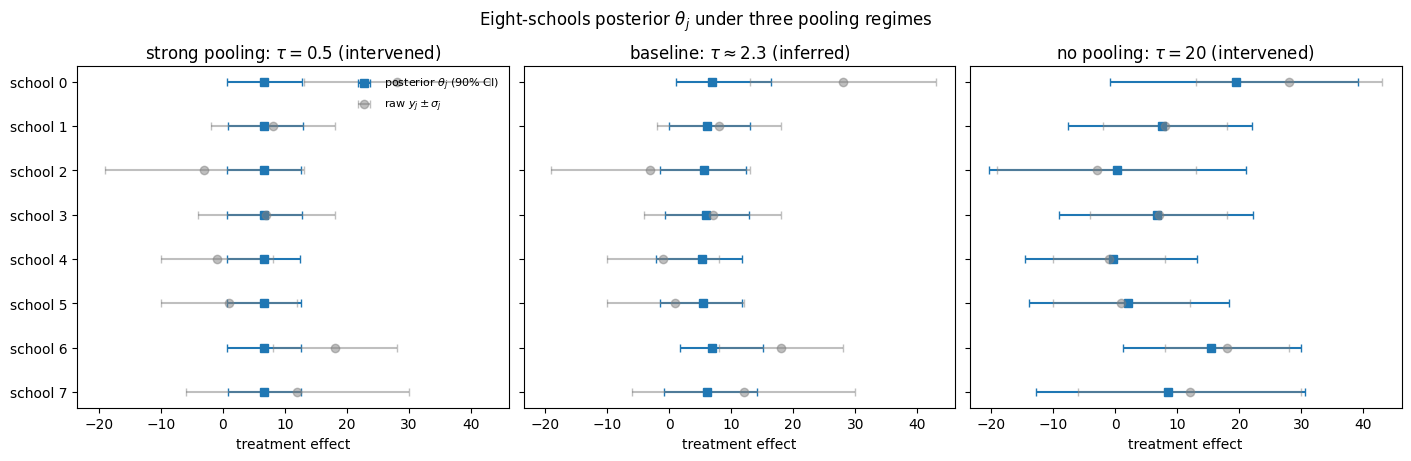

In [9]:
def forest(ax, samples_dict, title):
    means = np.array([float(samples_dict[f"theta_{j}"].mean())             for j in range(J)])
    lo    = np.array([float(np.quantile(samples_dict[f"theta_{j}"], 0.05)) for j in range(J)])
    hi    = np.array([float(np.quantile(samples_dict[f"theta_{j}"], 0.95)) for j in range(J)])
    ax.errorbar(means, np.arange(J),
                xerr=[means - lo, hi - means],
                fmt="s", color="C0", capsize=3, label=r"posterior $\theta_j$ (90% CI)")
    ax.errorbar(np.asarray(y_obs), np.arange(J), xerr=np.asarray(sigma_obs),
                fmt="o", color="gray", alpha=0.5, capsize=3, label=r"raw $y_j \pm \sigma_j$")
    ax.set_yticks(np.arange(J))
    ax.set_yticklabels([f"school {j}" for j in range(J)])
    ax.invert_yaxis()
    ax.set_xlabel("treatment effect")
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True, constrained_layout=True)
forest(axes[0], samples_strong, r"strong pooling: $\tau = 0.5$ (intervened)")
forest(axes[1], samples8,       r"baseline: $\tau \approx 2.3$ (inferred)")
forest(axes[2], samples_none,   r"no pooling: $\tau = 20$ (intervened)")
# Common x-range across panels so the spread is directly comparable.
lo_x = min(ax.get_xlim()[0] for ax in axes)
hi_x = max(ax.get_xlim()[1] for ax in axes)
for ax in axes:
    ax.set_xlim(lo_x, hi_x)
axes[0].legend(loc="upper right", frameon=False, fontsize=8)
fig.suptitle(r"Eight-schools posterior $\theta_j$ under three pooling regimes")
plt.show()

## Where to go next

- `tests/test_composition.py` — the differentiating tests: in-trace intervention, `fwd()` correctness, handler-nesting composition, hierarchical eight-schools, symbolic-indexing under MCMC.
- `tests/test_distributions.py` — every distribution in `effectful.handlers.numpyro` certified end-to-end through NUTS (modulo discrete-skip and a structural `Delta` exception).
- `docs/biject_to_compatibility.md` — `biject_to` spike output: which distributions need a small workaround for transform-based inference.